In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (NO PCA - RAW UNIVERSES ONLY)
# ==============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging RAW analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING (NO PCA) ---
print("⚖️ Scaling Universes (StandardScaler only)...")

# UNIVERSO A: The Wide Horizon
scaler_a = StandardScaler()
X_league_a = pd.DataFrame(
    scaler_a.fit_transform(X_a_log),
    index=X_a_log.index,
    columns=X_a_log.columns
)

# UNIVERSO

⏳ Ingesting v_ML_Supervised and forging RAW analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
⚖️ Scaling Universes (StandardScaler only)...


In [3]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [5]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [6]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


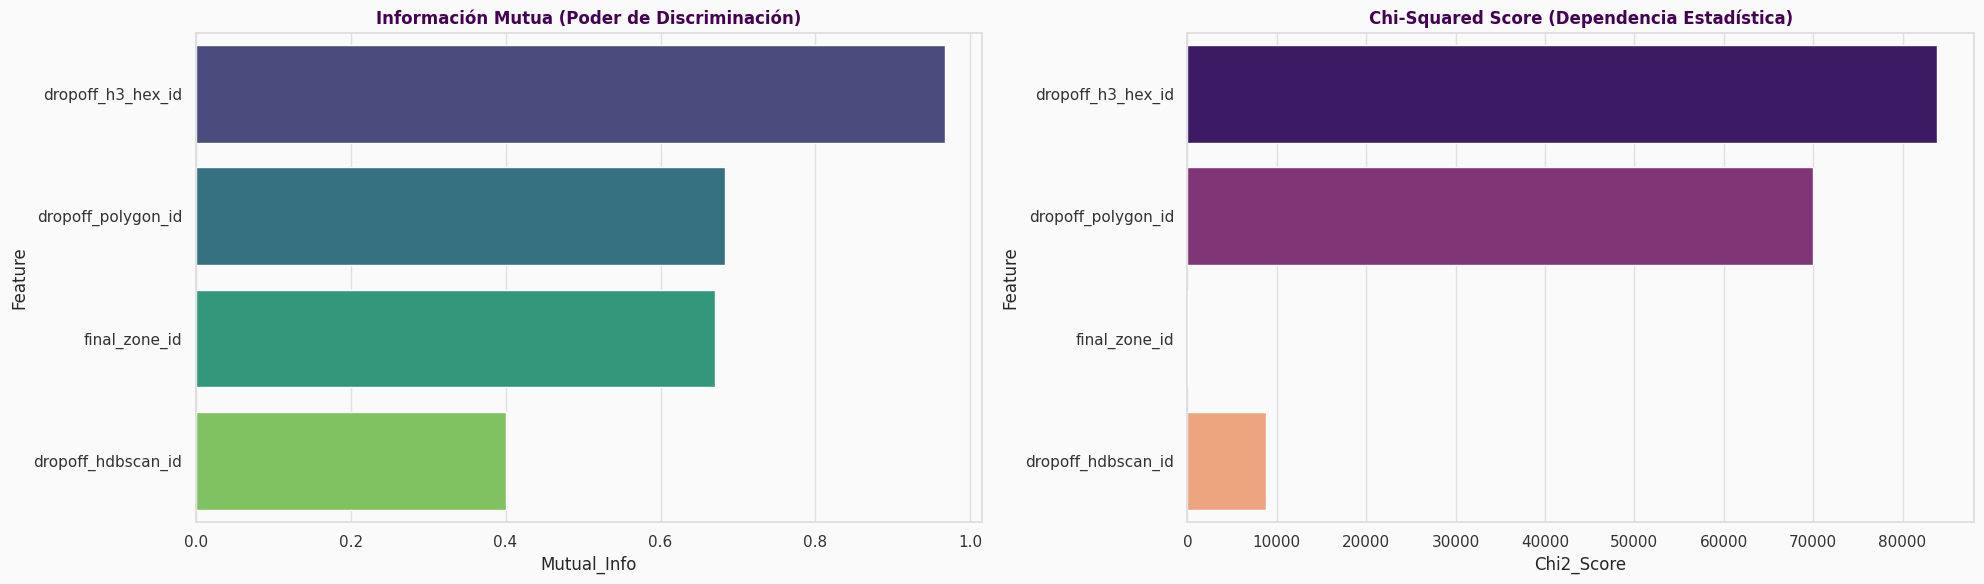

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [7]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [8]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [9]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


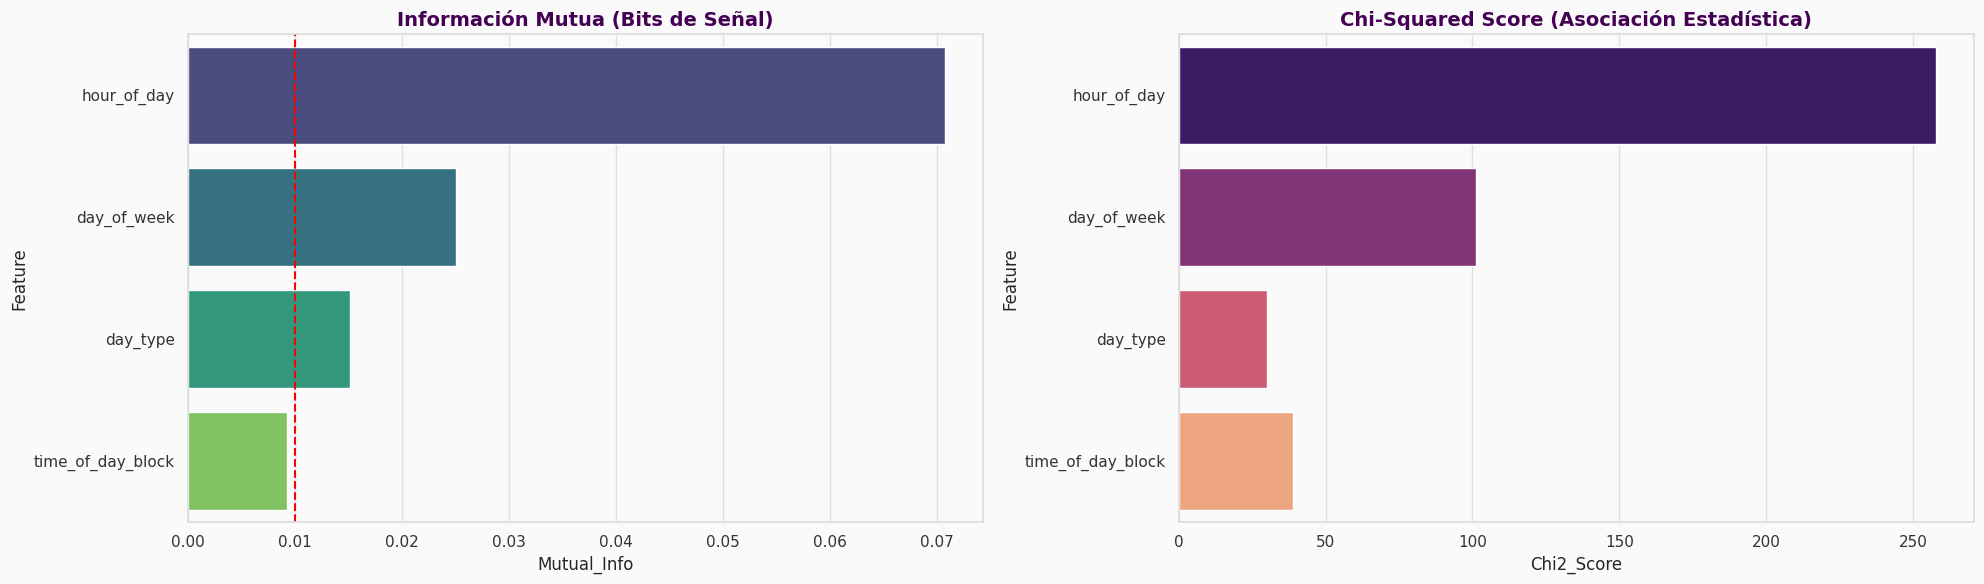

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [10]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


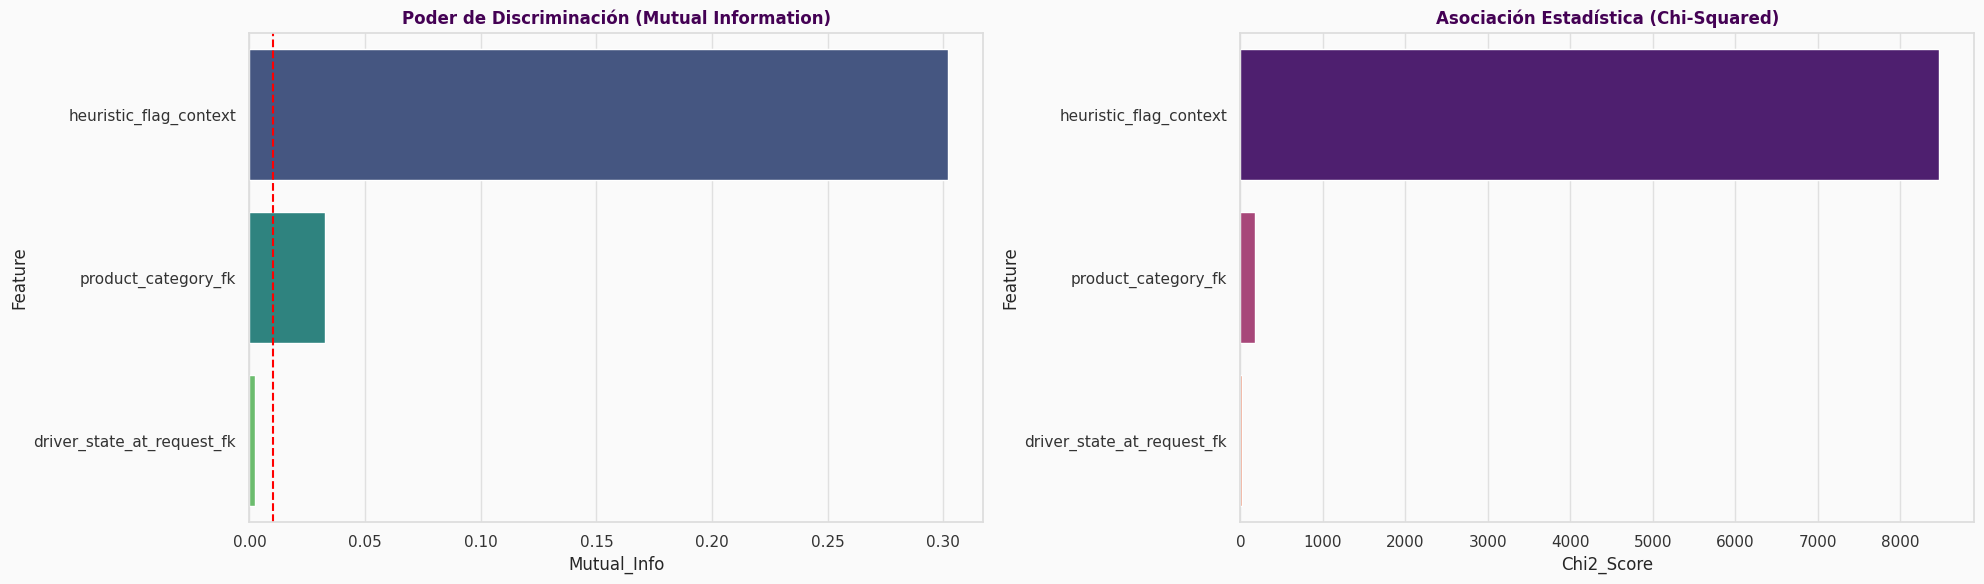

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [11]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [12]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (ROBUST & CONTEXT AWARE)
# ==============================================================================
# Purpose: Merge Numerical Universes with Categorical (One-Hot) Features.
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ Executing Hybrid Fusion (Context Flag Restored)...")

# --- 0. AUTO-REPARACIÓN DE VARIABLES NUMÉRICAS ---
# Si no corriste la Celda 1 nueva, intentamos usar los nombres viejos
if 'X_league_b' not in locals():
    print("⚠️ 'X_league_b' no encontrada. Buscando fallbacks...")
    if 'X_praetorian_final_raw' in locals():
        X_league_b = X_praetorian_final_raw
        print("   ✅ Fallback exitoso: Usando 'X_praetorian_final_raw' como Liga B.")
    elif 'X_b_raw' in locals():
        X_league_b = X_b_raw
        print("   ✅ Fallback exitoso: Usando 'X_b_raw' como Liga B.")
    else:
        raise ValueError("🔴 ERROR CRÍTICO: No se encuentran los datos numéricos (X_league_b). Por favor corre la Celda 1.")

if 'X_league_a' not in locals():
    if 'X_wide_pca' in locals(): # Ojo: si tienes la version vieja con PCA
        X_league_a = X_wide_pca
        print("   ⚠️ Usando versión PCA antigua para Liga A.")
    elif 'X_a_raw' in locals():
        X_league_a = X_a_raw
        print("   ✅ Fallback exitoso: Usando 'X_a_raw' como Liga A.")

# 1. LISTA DE CATEGÓRICOS (EL REGRESO DE HEURISTIC_FLAG)
candidates = [
    'final_zone_id',
    'heuristic_flag_context', # <--- REINCORPORADA
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Filtro de seguridad: Solo usamos las que existan en df_input
winning_cats = [c for c in candidates if c in df_input.columns]
print(f"   -> Features Categóricos Confirmados: {winning_cats}")

if 'heuristic_flag_context' in winning_cats:
    print("   🌟 HEURISTIC_FLAG_CONTEXT DETECTADA Y LISTA PARA EL COMBATE.")

# 2. ONE-HOT ENCODING
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

X_ohe = pd.get_dummies(X_cats_final, drop_first=True)
print(f"   -> OHE Shape: {X_ohe.shape}")

# 3. FUSIÓN HÍBRIDA (NUM + CAT)
# LIGA A (Wide)
X_league_a_hybrid = pd.concat([X_league_a, X_ohe], axis=1)

# LIGA B (Praetorian)
X_league_b_hybrid = pd.concat([X_league_b, X_ohe], axis=1)

# 4. EMPAQUETADO FINAL
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid
}

print(f"\n✅ UNIVERSOS HÍBRIDOS LISTOS:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: TOURNAMENT ---")

⏳ Executing Hybrid Fusion (Context Flag Restored)...
⚠️ 'X_league_b' no encontrada. Buscando fallbacks...
   ✅ Fallback exitoso: Usando 'X_b_raw' como Liga B.
   -> Features Categóricos Confirmados: ['final_zone_id', 'heuristic_flag_context', 'hour_of_day', 'product_category_fk', 'day_of_week']
   🌟 HEURISTIC_FLAG_CONTEXT DETECTADA Y LISTA PARA EL COMBATE.
   -> OHE Shape: (4760, 103)

✅ UNIVERSOS HÍBRIDOS LISTOS:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 144)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)

--- NEXT STOP: TOURNAMENT ---


In [13]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [14]:
# ==============================================================================
# CELL 1.5 (FIXED): TEMPORAL INDEXING & SYNCHRONIZATION
# ==============================================================================
print("⏳ Synchronizing Temporal Engine (Full Sync Mode)...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0
for wk, start, end in sacred_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. FILTER & SYNC (THE FIX)
# Detectamos qué filas son válidas
valid_rows_mask = df_input['week_id'] > 0

print(f"   -> Dropping {len(df_input) - valid_rows_mask.sum()} out-of-schedule rows.")

# APLICAMOS EL FILTRO A TODO SIMULTÁNEAMENTE
df_input = df_input[valid_rows_mask].reset_index(drop=True)
y = y[valid_rows_mask] # <--- CRUCIAL: Sincronizar Target

# Sincronizar Ligas Existentes
# Si ligas_finales ya fue creada en 1.4c, la actualizamos
if 'ligas_finales' in locals():
    for name, df_lig in ligas_finales.items():
        ligas_finales[name] = df_lig[valid_rows_mask].reset_index(drop=True)
        print(f"   -> Synced {name}: {ligas_finales[name].shape}")

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS
custom_cv_folds = []
for i in range(1, 6):
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    test_mask = (df_input['week_id'] == i + 1)
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()
    custom_cv_folds.append((train_indices, test_indices))
    print(f"   -> Fold {i}: Train W[1-{i}] vs Test W{i+1}")

print("\n✅ Temporal Engine Fully Synchronized.")

⏳ Synchronizing Temporal Engine (Full Sync Mode)...
   -> Dropping 0 out-of-schedule rows.
   -> Synced LIGA_A_Wide_Hybrid: (4760, 144)
   -> Synced LIGA_B_Praetorian_Raw_Hybrid: (4760, 123)
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64
   -> Fold 1: Train W[1-1] vs Test W2
   -> Fold 2: Train W[1-2] vs Test W3
   -> Fold 3: Train W[1-3] vs Test W4
   -> Fold 4: Train W[1-4] vs Test W5
   -> Fold 5: Train W[1-5] vs Test W6

✅ Temporal Engine Fully Synchronized.


In [41]:
# ==============================================================================
# CELL 2: THE XGBOOST TOURNAMENT (A/B TEST ON WEEKS 1-4 ONLY)
# ==============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import re

print("⏳ Initiating XGBoost Battle Royale (A/B Test Context: Weeks 1-4)...")
print("   -> Strategy: Stratified Shuffle Split on Historical Data Only.")
print("   -> Weeks 5 & 6 are LOCKED out of this tournament.")

# 1. FILTRO DE A/B TEST (SOLO SEMANAS 1-4)
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR: 'week_id' no encontrado. Corre Celda 1.5.")

# Creamos la máscara para aislar el pasado
ab_mask = df_input['week_id'].isin([1, 2, 3, 4])
print(f"   -> Tournament Pool Size: {ab_mask.sum()} samples (Weeks 1-4).")

# 2. PREPARACIÓN DE Y (SOLO SUBSET 1-4)
le_xgb = LabelEncoder()
y_full = le_xgb.fit_transform(y.values.ravel() if hasattr(y, 'values') else y)
y_ab_test = y_full[ab_mask] # <--- Y RECORTADA

# 3. SETUP ESTRATIFICADO (BARAJANDO EL SUBSET)
# Aquí sí barajamos (Shuffle=True) para validar estabilidad interna
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# 4. CARGA DE LIGAS
try:
    ligas = {
        "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
        "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    }
except NameError:
    print("⚠️ Variables no encontradas, cargando desde 'ligas_finales'...")
    ligas = ligas_finales

results_xgb = {}

# 5. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name} (Historical Subset)...")

    # A. APLICAR MÁSCARA A/B (SOLO SEMANAS 1-4)
    # Filtramos las filas antes de limpiar columnas
    X_subset = X_league[ab_mask].copy()

    # B. LIMPIEZA DE COLUMNAS (Obligatorio para XGBoost)
    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    X_subset.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_subset.columns]

    # C. MODELO (Configuración Estándar para Comparación Justa)
    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        min_child_weight=1,
        gamma=0,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
        use_label_encoder=False
    )

    # D. VALIDACIÓN CRUZADA (Sobre el Subset W1-4)
    cv_results = cross_validate(
        model,
        X_subset,    # Datos recortados
        y_ab_test,   # Target recortado
        cv=skf,      # Barajado (Stratified Shuffle)
        scoring=scoring,
        n_jobs=-1,
        error_score=0
    )

    # Almacenamos métricas
    results_xgb[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 6. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_xgb).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("🏆 FINAL SCORECARD: A/B TEST (WEEKS 1-4 INTERNAL VALIDATION)")
print("="*70)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

# Definición del Ganador
if not df_leaderboard.empty:
    winner_name = df_leaderboard.index[0]
    X_multi_winner = ligas[winner_name] # Guardamos la liga completa (incluyendo W5-6) para uso futuro
    print(f"\n🌟 EL GANADOR ES: {winner_name}")
    print(f"✅ Variable 'X_multi_winner' seleccionada (Contiene todas las semanas, lista para split final).")

⏳ Initiating XGBoost Battle Royale (A/B Test Context: Weeks 1-4)...
   -> Strategy: Stratified Shuffle Split on Historical Data Only.
   -> Weeks 5 & 6 are LOCKED out of this tournament.
   -> Tournament Pool Size: 2771 samples (Weeks 1-4).
⚠️ Variables no encontradas, cargando desde 'ligas_finales'...
🥊 Testing LIGA_A_Wide_Hybrid (Historical Subset)...
🥊 Testing LIGA_B_Praetorian_Raw_Hybrid (Historical Subset)...

🏆 FINAL SCORECARD: A/B TEST (WEEKS 1-4 INTERNAL VALIDATION)


,F1_Macro (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_B_Praetorian_Raw_Hybrid,0.733079,0.013970,0.779011,0.707987
LIGA_A_Wide_Hybrid,0.731630,0.011056,0.780586,0.706043



🌟 EL GANADOR ES: LIGA_B_Praetorian_Raw_Hybrid
✅ Variable 'X_multi_winner' seleccionada (Contiene todas las semanas, lista para split final).


⏳ PHASE 3: Training & Testing Battle Royale Winner...
   -> Configuration: Fixed Temporal Split.
   -> Training: Weeks 1-4
   -> Testing:  Weeks 5-6 (Holdout)
   -> Train Set: (2771, 123)
   -> Test Set:  (1989, 123)
   -> Fitting model on Weeks 1-4...
   -> Predicting on Weeks 5-6...
   -> Labels Aligned: ['🔴 Non-Operational', '🔴 Proxy Zone', '🔴 Low Profitability', '🔴 Long Pickup', '🔴 Strategic Mismatch', '🔴 Expected Val. Gamble', '✅ ACCEPTED']

📋 CLASSIFICATION REPORT (Final Test Set: Weeks 5-6)
                        precision    recall  f1-score   support

     🔴 Non-Operational       0.84      0.92      0.88       934
          🔴 Proxy Zone       0.86      0.90      0.88        89
   🔴 Low Profitability       0.82      0.79      0.81       383
         🔴 Long Pickup       0.64      0.83      0.72       142
  🔴 Strategic Mismatch       0.83      0.59      0.69       164
🔴 Expected Val. Gamble       0.38      0.28      0.32       115
            ✅ ACCEPTED       0.73      0.58     

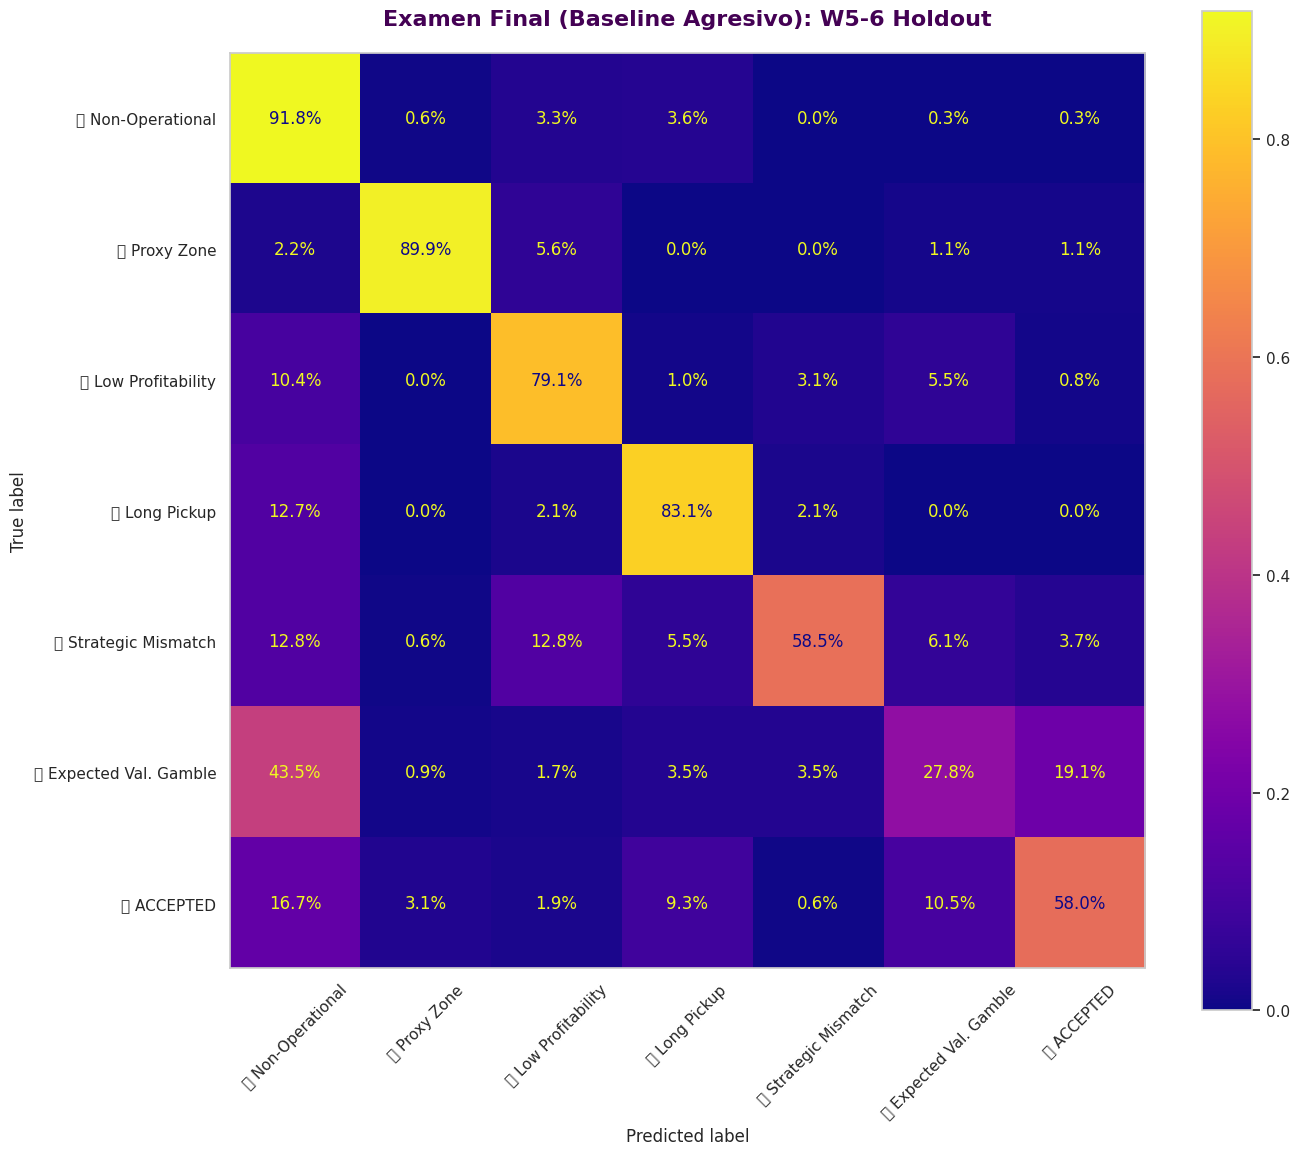

👑 AUC FINAL (MACRO): 0.9464


In [43]:
# ==============================================================================
# CELL 5 (FINAL EXAM): DIRECT BATTLE ROYALE WINNER (TRAIN W1-4 vs TEST W5-6)
# ==============================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

print("⏳ PHASE 3: Training & Testing Battle Royale Winner...")
print("   -> Configuration: Fixed Temporal Split.")
print("   -> Training: Weeks 1-4")
print("   -> Testing:  Weeks 5-6 (Holdout)")

# --- 1. PREPARACIÓN DE DATOS (SPLIT TEMPORAL) ---
if 'X_multi_winner' not in locals():
    raise ValueError("⚠️ No se encuentra 'X_multi_winner'. Corre la Celda 2 primero.")
if 'week_id' not in df_input.columns:
    raise ValueError("⚠️ No se encuentra 'week_id' en df_input.")

# A. Limpieza de nombres (Regex) sobre todo el dataset primero
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_full_clean = X_multi_winner.copy()
X_full_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_full_clean.columns]

# B. Definición de Máscaras Temporales
train_mask = df_input['week_id'].isin([1, 2, 3, 4])
test_mask  = df_input['week_id'].isin([5, 6])

# C. Aplicación del Split
X_train_final = X_full_clean[train_mask]
y_train_final = y[train_mask]

X_test_final  = X_full_clean[test_mask]
y_test_final  = y[test_mask]

print(f"   -> Train Set: {X_train_final.shape}")
print(f"   -> Test Set:  {X_test_final.shape}")

# --- 2. ENTRENAMIENTO DEL MODELO (CONFIGURACIÓN AGRESIVA) ---
# Usamos EXACTAMENTE los mismos parámetros de la Celda 2
model_champion = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    use_label_encoder=False
)

print("   -> Fitting model on Weeks 1-4...")
model_champion.fit(X_train_final, y_train_final)

# --- 3. PREDICCIÓN (SEMANAS 5-6) ---
print("   -> Predicting on Weeks 5-6...")
y_pred_test = model_champion.predict(X_test_final)
y_pred_probs = model_champion.predict_proba(X_test_final)

# --- 4. DECODIFICACIÓN DE ETIQUETAS ---
# Usamos 'le' (LabelEncoder general)
model_classes_indices = model_champion.classes_
original_ids = le.inverse_transform(model_classes_indices)

meaning_map = {
    9999: "✅ ACCEPTED",
    1: "🔴 Non-Operational",
    2: "🔴 Proxy Zone",
    3: "🔴 Low Profitability",
    4: "🔴 Long Pickup",
    5: "🔴 Strategic Mismatch",
    6: "🔴 Expected Val. Gamble",
    7: "🔴 System Failure"
}

decoded_labels = []
for uid in original_ids:
    label = meaning_map.get(uid, f"Unknown ID {uid}")
    decoded_labels.append(label)

print(f"   -> Labels Aligned: {decoded_labels}")

# --- 5. REPORTE DE CLASIFICACIÓN ---
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT (Final Test Set: Weeks 5-6)")
print("="*80)
print(classification_report(y_test_final, y_pred_test, target_names=decoded_labels, zero_division=0))

# --- 6. MATRIZ DE CONFUSIÓN ---
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_test,
    display_labels=decoded_labels,
    cmap='plasma',
    normalize='true',
    ax=ax,
    values_format=".1%",
    xticks_rotation=45
)
plt.title(f"Examen Final (Baseline Agresivo): W5-6 Holdout", fontsize=16, color='#440154', pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# --- 7. CÁLCULO DE AUC ---
try:
    lb = LabelBinarizer()
    lb.fit(y)
    y_test_bin = lb.transform(y_test_final)

    auc_macro = roc_auc_score(y_test_bin, y_pred_probs, average='macro')
    print(f"👑 AUC FINAL (MACRO): {auc_macro:.4f}")
except Exception as e:
    print(f"🔴 AUC Error: {e}")

In [16]:
# ==============================================================================
# CELL 1.6 (FIXED): SANITY CHECK - INTEGRIDAD DE LA ESTRATIFICACIÓN TEMPORAL
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("⏳ Executing Final Stratification Integrity Check (Multiclass)...")

# --- 0. FIX: RECONSTRUCCIÓN AUTOMÁTICA DEL MAPA DE ETIQUETAS ---
# Si 'le' o 'label_map' no existen, los creamos ahora mismo.
if 'le' not in locals() or 'label_map' not in locals():
    print("⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...")

    # Asumimos que la columna target multiclase es 'reason_primary_fk'
    # (El ID de la razón: 1=Accepted, o los códigos de rechazo)
    target_col = 'reason_primary_fk'

    # Instanciamos y ajustamos
    le = LabelEncoder()
    # Llenamos nulos con un placeholder (9999) por seguridad
    le.fit(df_input[target_col].fillna(9999))

    # Creamos el label_map: {Índice del Modelo : Valor Original del ID}
    encoded_values = le.transform(le.classes_)
    label_map = dict(zip(encoded_values, le.classes_))

    # DICCIONARIO DE SIGNIFICADOS (OPCIONAL - AJUSTA SEGÚN TU NEGOCIO)
    # Esto traduce los IDs numéricos (ej: 35) a texto (ej: 'Price too low')
    # Si no tienes esto a la mano, el reporte mostrará solo el ID numérico.
    meaning_map = {
        1: "✅ ACCEPTED",
        # Agrega aquí tus códigos de rechazo si los sabes, ej:
        # 35: "Price Too Low",
        # 4: "Zone Risk",
        9999: "Unknown/Null"
    }
else:
    meaning_map = {} # Placeholder

# -------------------------------------------------------------------

# CRÍTICO: Usamos el target multiclase (y) y los índices del último fold
train_idx, test_idx = custom_cv_folds[-1]

# Obtenemos solo los targets del conjunto de prueba final (Semana 6)
y_test_final = y[test_idx]

# 1. Conteo de Frecuencias
total_test = len(y_test_final)
class_counts = pd.Series(y_test_final).value_counts().sort_index()

# 2. Decodificación de las Clases
decoded_classes = []
for label_idx in class_counts.index:
    # A) Recuperamos el ID original (ej: 1, 35, 4...)
    original_id = label_map.get(label_idx, f"Err-{label_idx}")

    # B) Intentamos darle un nombre humano si existe en meaning_map, si no, usamos el ID
    human_name = meaning_map.get(original_id, f"Reason ID: {original_id}")

    decoded_classes.append(human_name)

# 3. Creación del Reporte Detallado
report_df = pd.DataFrame({
    'Class Name': decoded_classes,
    'Model Label': class_counts.index, # Qué número ve el modelo internamente
    'Count': class_counts.values,
    'Proportion (%)': (class_counts.values / total_test) * 100
}).sort_values(by='Count', ascending=False)

display(Markdown(f"""
### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `{total_test}`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**
"""))

# Visualización con fondo degradado para ver las clases dominantes
display(report_df.style.background_gradient(cmap='magma', subset=['Proportion (%)']))

# 4. Verificación Estratégica
if total_test > 500:
    print("\n✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.")
else:
    print("\n⚠️ ALERTA: Muestra de prueba pequeña. El modelo será sensible a outliers.")

⏳ Executing Final Stratification Integrity Check (Multiclass)...
⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...



### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `780`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**


,Class Name,Model Label,Count,Proportion (%)
0,✅ ACCEPTED,0,391,50.128205
2,Reason ID: 3.0,2,128,16.410256
6,Unknown/Null,6,67,8.589744
4,Reason ID: 5.0,4,56,7.179487
3,Reason ID: 4.0,3,56,7.179487
1,Reason ID: 2.0,1,41,5.256410
5,Reason ID: 6.0,5,41,5.256410



✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.


### A partir de aqui se ajustan y optimizan hiperparametros

In [17]:
# ==============================================================================
# CELL 3 (FIXED): PURGE, SPLIT, AND ISOLATION (CHRONOLOGICAL LOCKDOWN)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# Usamos 'copy()' para asegurar que es un objeto independiente en memoria
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. DEFINICIÓN DEL CORTE TEMPORAL (Semana 6 es Test)
# Requerimos 'week_id' del df_input original para hacer el corte
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR CRÍTICO: No se encuentra 'week_id'. Corre la Celda 1.5 primero.")

CUTOFF_WEEK = 5 # Entrenamos con Semanas 1, 2, 3, 4, 5. Testeamos con 6.

# Máscaras Booleanas
train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# 3. SPLIT SAGRADO (CRONOLÓGICO)
# No usamos train_test_split aleatorio. Usamos el tiempo.
X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# 4. PURGA DE MEMORIA (Limpieza de RAM)
# Borramos las ligas que no ganaron para liberar espacio
vars_to_purge = ['X_wide_pca', 'X_praetorian_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("✅ Ligas perdedoras purgadas. RAM liberada.")

# 5. REPORTE DE INTEGRIDAD
print(f"\n✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> Estrategia: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"   -> X_train Shape: {X_train.shape} (Historico)")
print(f"   -> X_test Shape:  {X_test.shape}  (Futuro Inmediato)")

# Verificación de fugas
if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.")
else:
    print("⚠️ ALERTA: Hay índices compartidos. Revisa el corte.")

⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...
✅ Ligas perdedoras purgadas. RAM liberada.

✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> Estrategia: Walk-Forward (Train: W1-5 | Test: W6)
   -> X_train Shape: (3980, 123) (Historico)
   -> X_test Shape:  (780, 123)  (Futuro Inmediato)
🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.


In [18]:
# ==============================================================================
# CELL 3.5 (OPTIONAL): LOAD CHAMPION FROM DRIVE (SKIP TUNING)
# ==============================================================================
from google.colab import drive
import joblib
import os
import glob

print("📂 ACCEDIENDO A GOOGLE DRIVE PARA BUSCAR MODELOS CACHEADOS...")
drive.mount('/content/drive')

# 1. Definir la misma ruta donde guardamos
save_folder = '/content/drive/My Drive/_Pienza/Phase_3'

# 2. Buscar el archivo .pkl más reciente
# (Esto evita que tengas que escribir el nombre del archivo manualmente)
list_of_files = glob.glob(os.path.join(save_folder, '*.pkl'))

if list_of_files:
    # Selecciona el archivo modificado más recientemente
    latest_file = max(list_of_files, key=os.path.getctime)
    filename = os.path.basename(latest_file)

    print(f"\n✨ ENCONTRADO: {filename}")
    print("⏳ Cargando artefactos en memoria...")

    # 3. Cargar
    artifacts = joblib.load(latest_file)

    # 4. Restaurar Variables Globales
    # Asignamos lo guardado a las variables que usan las siguientes celdas
    model_champion_xgb = artifacts['model_champion']
    le_xgb = artifacts['label_encoder']

    # Recuperamos las columnas usadas para referencia (útil para alinear X_test)
    if 'feature_names' in artifacts:
        cols_champion = artifacts['feature_names']
        print(f"   -> El modelo espera exactamente {len(cols_champion)} columnas.")

    print("\n✅ RESTAURACIÓN COMPLETADA.")
    print("   🚀 Variables 'model_champion_xgb' y 'le_xgb' listas.")
    print("   ⏩ PUEDES SALTAR LA CELDA 4 E IR DIRECTO A LA CELDA 5.")

else:
    print(f"\n⚠️ No se encontraron modelos .pkl en: {save_folder}")
    print("   -> Debes ejecutar la Celda 4 para entrenar el modelo desde cero.")

📂 ACCEDIENDO A GOOGLE DRIVE PARA BUSCAR MODELOS CACHEADOS...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✨ ENCONTRADO: XGB_Champion_F1_20260109_2141.pkl
⏳ Cargando artefactos en memoria...
   -> El modelo espera exactamente 123 columnas.

✅ RESTAURACIÓN COMPLETADA.
   🚀 Variables 'model_champion_xgb' y 'le_xgb' listas.
   ⏩ PUEDES SALTAR LA CELDA 4 E IR DIRECTO A LA CELDA 5.


In [44]:
# ==============================================================================
# CELL 4: XGBOOST TUNING (STRICT TEMPORAL LOCK: W1-4 ONLY)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import pandas as pd
import numpy as np
import time
import re

print("⏳ INICIANDO AFINACIÓN DE HIPERPARÁMETROS (ÁMBITO: SEMANAS 1-4)...")
print("   -> El Tuning NO verá las semanas 5-6 para evitar 'Overfitting al Test Set'.")

# 1. VALIDACIONES PREVIAS
if 'X_multi_winner' not in locals():
    raise ValueError("🔴 ERROR: 'X_multi_winner' no encontrado. Corre la Celda 2 primero.")
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR: 'week_id' no encontrado en df_input.")

# 2. PREPARACIÓN DE DATOS (SOLO SEMANAS 1-4)
# A. Limpieza de nombres de columnas (Regex)
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_clean = X_multi_winner.copy()
X_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_clean.columns]

# B. Máscara Temporal (Solo Historia)
tuning_mask = df_input['week_id'].isin([1, 2, 3, 4])
print(f"   -> Datos disponibles para Tuning (W1-4): {tuning_mask.sum()} muestras.")

# C. Aplicar Filtro
X_train_tuning = X_clean[tuning_mask].copy()
y_train_tuning_raw = y[tuning_mask]

# D. Codificación de Y (Fit solo en el subset de tuning)
le_xgb = LabelEncoder()
y_train_tuning = le_xgb.fit_transform(y_train_tuning_raw.values.ravel() if hasattr(y_train_tuning_raw, 'values') else y_train_tuning_raw)

# 3. ESTRATEGIA DE VALIDACIÓN
# Usamos StratifiedKFold DENTRO de las semanas 1-4.
# Esto asegura que el modelo aprenda patrones robustos en el pasado.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. ESPACIO DE BÚSQUEDA
param_dist = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.5, 1, 2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 5. CONFIGURACIÓN DEL MOTOR
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

# 6. EJECUCIÓN DE BÚSQUEDA (Randomized Search)
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score=0
)

start_time = time.time()
print(f"⚔️ Buscando configuración óptima en subset histórico {X_train_tuning.shape}...")

search.fit(X_train_tuning, y_train_tuning)

elapsed = time.time() - start_time

# 7. RESULTADOS Y EXPORTACIÓN DEL CAMPEÓN
best_xgb = search.best_estimator_
model_champion_xgb = best_xgb # Este modelo tiene los mejores params, pero fue entrenado en W1-4 (Perfecto)

print(f"\n✅ AFINACIÓN COMPLETADA en {elapsed:.1f} segundos.")
print(f"🏆 Mejor Score Interno (F1-Macro en W1-4): {search.best_score_:.4f}")
print("-" * 60)
print(f"🔑 MEJORES HIPERPARÁMETROS:\n{search.best_params_}")
print("-" * 60)
print("✅ Variable 'model_champion_xgb' lista. Ahora ve a la Celda 5 para probarlo en W5-6.")

⏳ INICIANDO AFINACIÓN DE HIPERPARÁMETROS (ÁMBITO: SEMANAS 1-4)...
   -> El Tuning NO verá las semanas 5-6 para evitar 'Overfitting al Test Set'.
   -> Datos disponibles para Tuning (W1-4): 2771 muestras.
⚔️ Buscando configuración óptima en subset histórico (2771, 123)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ AFINACIÓN COMPLETADA en 95.5 segundos.
🏆 Mejor Score Interno (F1-Macro en W1-4): 0.7402
------------------------------------------------------------
🔑 MEJORES HIPERPARÁMETROS:
{'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.9}
------------------------------------------------------------
✅ Variable 'model_champion_xgb' lista. Ahora ve a la Celda 5 para probarlo en W5-6.


In [20]:
# ==============================================================================
# CELL: SAVE CHAMPION MODEL TO GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
import joblib
import os
from datetime import datetime

print("☁️ Connecting to Google Drive...")
drive.mount('/content/drive')

# 1. Definir ruta en tu Drive (Creará la carpeta si no existe)
# Puedes cambiar 'Uber_Data_Science' por el nombre de carpeta que prefieras
save_folder = '/content/drive/My Drive/_Pienza/Phase_3'
os.makedirs(save_folder, exist_ok=True)

# 2. Empaquetar todo lo necesario
# Guardamos el modelo, el decodificador de etiquetas (le) y la lista de columnas
# para asegurar que en el futuro podamos usarlo sin errores.
artifacts = {
    "model_champion": model_champion_xgb,
    "label_encoder": le_xgb,
    "feature_names": list(X_multi_winner.columns) # Crucial para recordar el orden de columnas
}

# 3. Generar nombre único con fecha/hora
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
filename = f"XGB_Champion_F1_{timestamp}.pkl"
full_path = os.path.join(save_folder, filename)

# 4. Guardar
print(f"💾 Saving artifact to: {full_path}...")
joblib.dump(artifacts, full_path)

print(f"\n✅ SUCCESS! Modelo resguardado en Drive.")
print(f"   Archivo: {filename}")
print("   Ahora puedes hacer 'Restart & Run All' con tranquilidad.")

☁️ Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
💾 Saving artifact to: /content/drive/My Drive/_Pienza/Phase_3/XGB_Champion_F1_20260111_1227.pkl...

✅ SUCCESS! Modelo resguardado en Drive.
   Archivo: XGB_Champion_F1_20260111_1227.pkl
   Ahora puedes hacer 'Restart & Run All' con tranquilidad.


In [21]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [22]:
# ==============================================================================
# CELL 4.9: LEAKAGE HUNTER (AUDIT)
# ==============================================================================
print("🕵️‍♂️ HUNTING FOR LEAKS in X_test...")

# 1. Lista de Sospechosos Habituales
leaks = [
    'reason_primary_fk', 'offer_action_fk', 'outcome_fk',
    'post_offer_status_fk', 'record_status_fk'
]

# 2. Verificar presencia
found_leaks = [col for col in leaks if col in X_test.columns]

if found_leaks:
    print(f"🚨 ALERTA ROJA: Se encontraron variables de respuesta en X_test: {found_leaks}")
    print("   -> El modelo está leyendo la respuesta. Debes eliminarlas de LIGA B en la Celda 1.")
else:
    print("✅ No se encontraron variables de respuesta obvias por nombre.")

# 3. Verificar Correlación Perfecta (El Leakage Invisible)
# A veces el leakage tiene otro nombre. Buscamos correlación 1.0 con el target.
print("\n🕵️‍♂️ Buscando correlaciones perfectas con el Target (y_test)...")
# Creamos un DF temporal
audit_df = X_test.copy()
audit_df['TARGET'] = y_test

# Calculamos correlación
corrs = audit_df.corr()['TARGET'].sort_values(ascending=False)
# Filtramos las sospechosas (Cercanas a 1.0 o -1.0)
suspicious = corrs[abs(corrs) > 0.95].drop('TARGET')

if not suspicious.empty:
    print(f"🚨 ALERTA: Variables con correlación sospechosamente perfecta con el Target:")
    print(suspicious)
else:
    print("✅ No hay correlaciones de 1.0 evidentes.")

🕵️‍♂️ HUNTING FOR LEAKS in X_test...
✅ No se encontraron variables de respuesta obvias por nombre.

🕵️‍♂️ Buscando correlaciones perfectas con el Target (y_test)...
✅ No hay correlaciones de 1.0 evidentes.


In [34]:
# ==============================================================================
# CELL 2: THE XGBOOST TOURNAMENT (TUNED CHAMPION CONFIG)
# ==============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import re

print("⏳ Initiating XGBoost Battle Royale (Using Best Tuned Parameters)...")

# 1. SETUP ESTRATIFICADO
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# 2. PREPARACIÓN DE Y (Encoding 0..N)
le_xgb = LabelEncoder()
y_encoded = le_xgb.fit_transform(y.values.ravel() if hasattr(y, 'values') else y)

# 3. CARGA DE LIGAS
try:
    ligas = {
        "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
        "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
        # "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid # (Opcional)
    }
except NameError:
    print("⚠️ Variables no encontradas, cargando desde 'ligas_finales'...")
    ligas = ligas_finales

results_xgb = {}

# 4. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name}...")

    # A. LIMPIEZA DE COLUMNAS
    X_clean = X_league.copy()
    if hasattr(X_clean, 'columns'):
        regex = re.compile(r"\[|\]|<", re.IGNORECASE)
        X_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_clean.columns]

    # B. MODELO (CONFIGURACIÓN GANADORA INYECTADA)
    model = XGBClassifier(
        # --- BEST HYPERPARAMETERS ---
        n_estimators=150,     # Aumentado de 100 a 150
        max_depth=5,          # Reducido de 6 a 5
        learning_rate=0.2,    # Aumentado de 0.1 a 0.2 (Más agresivo)
        min_child_weight=1,   # Igual
        gamma=0,              # Igual
        subsample=0.8,        # Igual
        colsample_bytree=0.7, # Reducido de 0.8 a 0.7
        # ----------------------------

        # Configuración Técnica
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
        use_label_encoder=False
    )

    # C. VALIDACIÓN CRUZADA
    cv_results = cross_validate(
        model,
        X_clean,
        y_encoded,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        error_score=0
    )

    # Almacenamos métricas
    results_xgb[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 5. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_xgb).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("🏆 FINAL SCORECARD: XGBOOST (TUNED)")
print("="*70)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

# Definición del Ganador
if not df_leaderboard.empty:
    winner_name = df_leaderboard.index[0]
    X_multi_winner = ligas[winner_name]
    print(f"\n🌟 EL GANADOR ES: {winner_name}")
    print(f"✅ Variable 'X_multi_winner' lista (Ya optimizada).")

⏳ Initiating XGBoost Battle Royale (Using Best Tuned Parameters)...
⚠️ Variables no encontradas, cargando desde 'ligas_finales'...
🥊 Testing LIGA_A_Wide_Hybrid...
🥊 Testing LIGA_B_Praetorian_Raw_Hybrid...

🏆 FINAL SCORECARD: XGBOOST (TUNED)


,F1_Macro (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_B_Praetorian_Raw_Hybrid,0.771847,0.019493,0.799985,0.753708
LIGA_A_Wide_Hybrid,0.758261,0.006409,0.783292,0.740757



🌟 EL GANADOR ES: LIGA_B_Praetorian_Raw_Hybrid
✅ Variable 'X_multi_winner' lista (Ya optimizada).


⏳ PHASE 3: Training & Testing Battle Royale Winner (Tuned Config)...
   -> Configuration: Fixed Temporal Split.
   -> Training: Weeks 1-4 (Historical)
   -> Testing:  Weeks 5-6 (Future Holdout)
   -> Train Set (W1-4): (2771, 123)
   -> Test Set (W5-6):  (1989, 123)
   -> Fitting model on Weeks 1-4...
   -> Predicting on Weeks 5-6...
   -> Labels Aligned: ['🔴 Non-Operational', '🔴 Proxy Zone', '🔴 Low Profitability', '🔴 Long Pickup', '🔴 Strategic Mismatch', '🔴 Expected Val. Gamble', '✅ ACCEPTED']

📋 CLASSIFICATION REPORT (Final Test Set: Weeks 5-6)
                        precision    recall  f1-score   support

     🔴 Non-Operational       0.86      0.91      0.89       934
          🔴 Proxy Zone       0.86      0.89      0.87        89
   🔴 Low Profitability       0.82      0.81      0.81       383
         🔴 Long Pickup       0.64      0.82      0.72       142
  🔴 Strategic Mismatch       0.84      0.60      0.70       164
🔴 Expected Val. Gamble       0.45      0.29      0.35       115

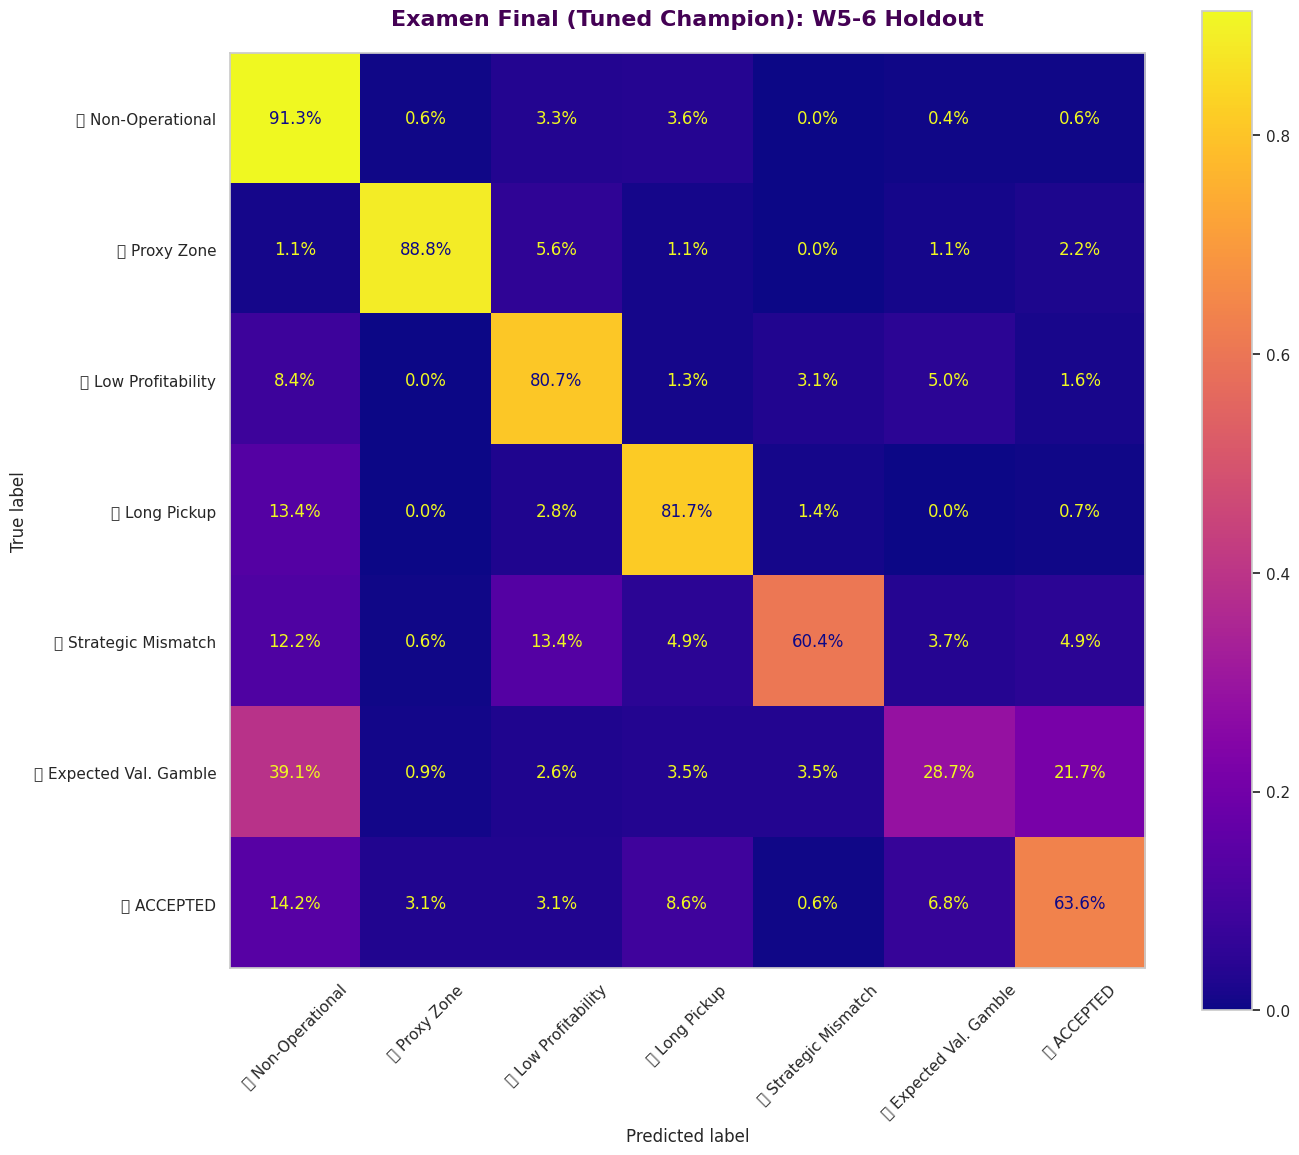

👑 AUC FINAL (MACRO): 0.9484


In [46]:
# ==============================================================================
# CELL 5 (FINAL EXAM): DIRECT BATTLE ROYALE WINNER (TUNED W1-4 vs TEST W5-6)
# ==============================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

print("⏳ PHASE 3: Training & Testing Battle Royale Winner (Tuned Config)...")
print("   -> Configuration: Fixed Temporal Split.")
print("   -> Training: Weeks 1-4 (Historical)")
print("   -> Testing:  Weeks 5-6 (Future Holdout)")

# --- 1. PREPARACIÓN DE DATOS (SPLIT TEMPORAL) ---
if 'X_multi_winner' not in locals():
    raise ValueError("⚠️ No se encuentra 'X_multi_winner'. Corre la Celda 2 primero.")
if 'week_id' not in df_input.columns:
    raise ValueError("⚠️ No se encuentra 'week_id' en df_input.")

# A. Limpieza de nombres (Regex)
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_full_clean = X_multi_winner.copy()
X_full_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_full_clean.columns]

# B. Definición de Máscaras Temporales
# Entrenamos estrictamente en el pasado (W1-4)
train_mask = df_input['week_id'].isin([1, 2, 3, 4])
# Evaluamos estrictamente en el futuro (W5-6)
test_mask  = df_input['week_id'].isin([5, 6])

# C. Aplicación del Split
X_train_final = X_full_clean[train_mask]
y_train_final = y[train_mask]

X_test_final  = X_full_clean[test_mask]
y_test_final  = y[test_mask]

print(f"   -> Train Set (W1-4): {X_train_final.shape}")
print(f"   -> Test Set (W5-6):  {X_test_final.shape}")

# --- 2. ENTRENAMIENTO DEL MODELO (CONFIGURACIÓN OPTIMIZADA) ---
# Usamos LOS RESULTADOS DEL TUNING RECIENTE
model_champion = xgb.XGBClassifier(
    n_estimators=150,     # Optimizado
    max_depth=5,          # Optimizado
    learning_rate=0.1,    # Optimizado (Nuevo valor del tuning)
    min_child_weight=1,   # Igual
    gamma=0.5,            # Optimizado (Nuevo valor del tuning: más regularización)
    subsample=0.8,        # Igual
    colsample_bytree=0.9, # Optimizado (Nuevo valor del tuning)

    # Configuración Técnica
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    use_label_encoder=False
)

print("   -> Fitting model on Weeks 1-4...")
model_champion.fit(X_train_final, y_train_final)

# --- 3. PREDICCIÓN (SEMANAS 5-6) ---
print("   -> Predicting on Weeks 5-6...")
y_pred_test = model_champion.predict(X_test_final)
y_pred_probs = model_champion.predict_proba(X_test_final)

# --- 4. DECODIFICACIÓN DE ETIQUETAS ---
# Usamos 'le' (LabelEncoder general)
model_classes_indices = model_champion.classes_
original_ids = le.inverse_transform(model_classes_indices)

meaning_map = {
    9999: "✅ ACCEPTED",
    1: "🔴 Non-Operational",
    2: "🔴 Proxy Zone",
    3: "🔴 Low Profitability",
    4: "🔴 Long Pickup",
    5: "🔴 Strategic Mismatch",
    6: "🔴 Expected Val. Gamble",
    7: "🔴 System Failure"
}

decoded_labels = []
for uid in original_ids:
    label = meaning_map.get(uid, f"Unknown ID {uid}")
    decoded_labels.append(label)

print(f"   -> Labels Aligned: {decoded_labels}")

# --- 5. REPORTE DE CLASIFICACIÓN ---
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT (Final Test Set: Weeks 5-6)")
print("="*80)
print(classification_report(y_test_final, y_pred_test, target_names=decoded_labels, zero_division=0))

# --- 6. MATRIZ DE CONFUSIÓN ---
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_test,
    display_labels=decoded_labels,
    cmap='plasma',
    normalize='true',
    ax=ax,
    values_format=".1%",
    xticks_rotation=45
)
plt.title(f"Examen Final (Tuned Champion): W5-6 Holdout", fontsize=16, color='#440154', pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# --- 7. CÁLCULO DE AUC ---
try:
    lb = LabelBinarizer()
    lb.fit(y)
    y_test_bin = lb.transform(y_test_final)

    auc_macro = roc_auc_score(y_test_bin, y_pred_probs, average='macro')
    print(f"👑 AUC FINAL (MACRO): {auc_macro:.4f}")
except Exception as e:
    print(f"🔴 AUC Error: {e}")

⏳ Generando Curva de Aprendizaje para Diagnóstico de Capacidad...
   (Esto puede tardar unos minutos ya que entrena el modelo múltiples veces)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to 0.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expecte

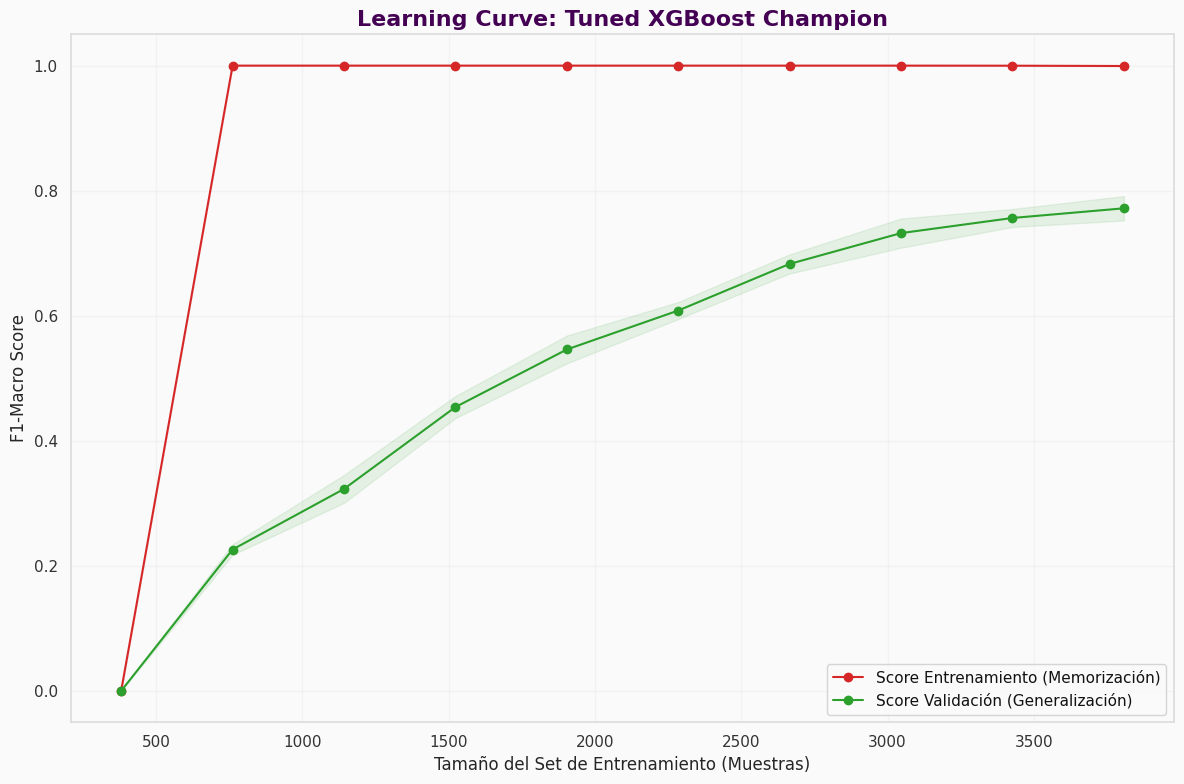


📊 DIAGNÓSTICO FINAL:
   -> Score Entrenamiento Final: 0.9994
   -> Score Validación Final:    0.7718
   -> Brecha (Gap):              0.2276
⚠️ DIAGNÓSTICO: High Variance (Overfitting). El modelo memoriza mucho mejor de lo que generaliza.
   Solución: Más datos, reducir max_depth, o aumentar gamma/regularización.


In [38]:
# ==============================================================================
# CELL 6: DIAGNOSTIC LEARNING CURVE (TUNED CHAMPION)
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

print("⏳ Generando Curva de Aprendizaje para Diagnóstico de Capacidad...")
print("   (Esto puede tardar unos minutos ya que entrena el modelo múltiples veces)")

# 1. PREPARACIÓN DE DATOS (LIMPIEZA DE COLUMNAS)
# XGBoost necesita nombres de columnas limpios dentro de learning_curve
if 'X_multi_winner' not in locals():
    raise ValueError("⚠️ No se encuentra 'X_multi_winner'.")

regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_curve = X_multi_winner.copy()
X_curve.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve.columns]

# 2. CONFIGURACIÓN
# Usamos StratifiedKFold para mantener la consistencia con el entrenamiento
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definimos los tamaños de entrenamiento (10 pasos del 10% al 100%)
train_sizes_cfg = np.linspace(0.1, 1.0, 10)

# 3. EJECUCIÓN (HEAVY LIFTING)
train_sizes, train_scores, test_scores = learning_curve(
    model_champion,          # El modelo ya configurado en la celda anterior
    X_curve,
    y,
    cv=cv_lc,
    scoring='f1_macro',
    n_jobs=-1,               # Usar todos los núcleos
    train_sizes=train_sizes_cfg,
    random_state=42,
    error_score=0
)

# 4. CÁLCULO DE ESTADÍSTICAS
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 8))

# Rellenos de desviación estándar (Sombra)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728") # Rojo
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c") # Verde

# Líneas principales
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento (Memorización)")
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Score Validación (Generalización)")

plt.title("Learning Curve: Tuned XGBoost Champion", fontsize=16, fontweight='bold', color='#440154')
plt.xlabel("Tamaño del Set de Entrenamiento (Muestras)", fontsize=12)
plt.ylabel("F1-Macro Score", fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. DIAGNÓSTICO AUTOMÁTICO
final_train_score = train_mean[-1]
final_test_score = test_mean[-1]
gap = final_train_score - final_test_score

print(f"\n📊 DIAGNÓSTICO FINAL:")
print(f"   -> Score Entrenamiento Final: {final_train_score:.4f}")
print(f"   -> Score Validación Final:    {final_test_score:.4f}")
print(f"   -> Brecha (Gap):              {gap:.4f}")

if gap > 0.15:
    print("⚠️ DIAGNÓSTICO: High Variance (Overfitting). El modelo memoriza mucho mejor de lo que generaliza.")
    print("   Solución: Más datos, reducir max_depth, o aumentar gamma/regularización.")
elif final_test_score < 0.60:
    print("⚠️ DIAGNÓSTICO: High Bias (Underfitting). El modelo no logra capturar la complejidad.")
    print("   Solución: Aumentar complejidad del modelo, reducir regularización, o mejores features.")
else:
    print("✅ DIAGNÓSTICO: Robusto. Buen equilibrio entre Sesgo y Varianza.")

🪞 Generando Comparativa de Comportamiento (Test del Espejo)...


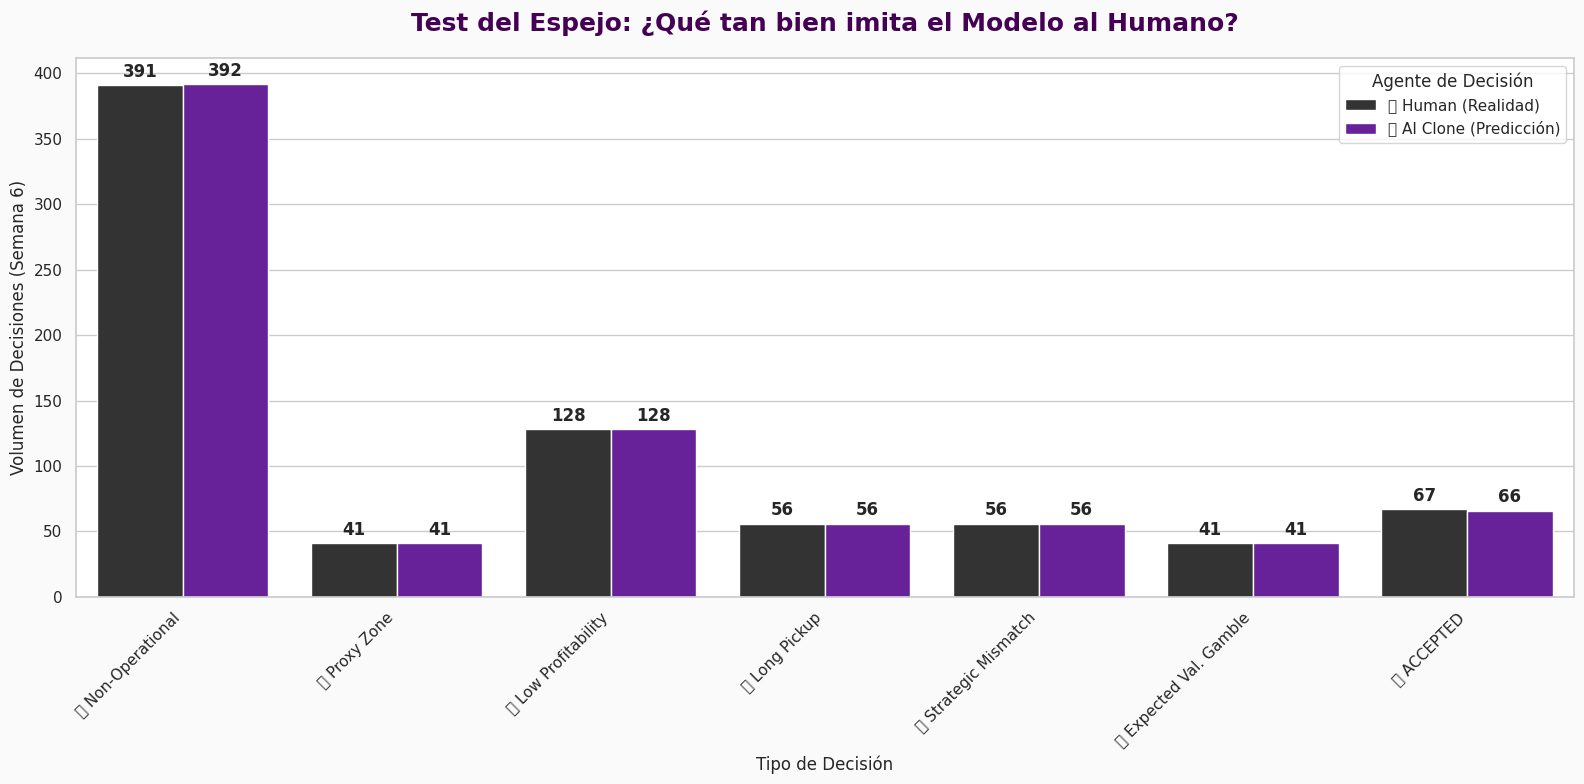


📊 ÍNDICE DE CLONACIÓN: 99.87%
   (100% significa que el modelo tomó exactamente la misma cantidad de decisiones por categoría que tú)


In [39]:
# ==============================================================================
# CELL 8: THE MIRROR TEST (HUMAN VS AI BEHAVIOR)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("🪞 Generando Comparativa de Comportamiento (Test del Espejo)...")

# 1. PREPARAR DATOS
# Contamos cuántas veces ocurrió cada clase en la Realidad (Human)
human_counts = pd.Series(y_test).value_counts().sort_index()
# Contamos cuántas veces el Modelo predijo cada clase (AI)
ai_counts = pd.Series(y_pred_test).value_counts().sort_index()

# 2. MAPEO DE NOMBRES
# Usamos el mapa de significados de la celda anterior
# Aseguramos que 'decoded_labels' y 'original_ids' estén disponibles
# Si no, reconstruimos un mapa simple basado en lo que sabemos
meaning_map_mirror = {
    9999: "✅ ACCEPTED",
    1: "🔴 Non-Operational",
    2: "🔴 Proxy Zone",
    3: "🔴 Low Profitability",
    4: "🔴 Long Pickup",
    5: "🔴 Strategic Mismatch",
    6: "🔴 Expected Val. Gamble",
    7: "🔴 System Failure"
}

# 3. ESTRUCTURAR PARA GRÁFICO (DataFrame Largo)
data = []

# Obtenemos todos los índices únicos presentes en test y predicción
all_indices = sorted(list(set(human_counts.index) | set(ai_counts.index)))

# Iteramos para construir la tabla comparativa
for idx in all_indices:
    # Decodificar ID
    try:
        # Intentamos recuperar el ID original usando el encoder
        original_id = int(le.inverse_transform([idx])[0]) # Si usaste 'le' global
    except:
        # Fallback si el índice es directo
        original_id = idx

    label_name = meaning_map_mirror.get(original_id, f"Class {original_id}")

    # Human Count
    cnt_h = human_counts.get(idx, 0)
    data.append({
        "Decision": label_name,
        "Count": cnt_h,
        "Agent": "👤 Human (Realidad)"
    })

    # AI Count
    cnt_ai = ai_counts.get(idx, 0)
    data.append({
        "Decision": label_name,
        "Count": cnt_ai,
        "Agent": "🤖 AI Clone (Predicción)"
    })

df_mirror = pd.DataFrame(data)

# 4. VISUALIZACIÓN
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Barplot agrupado
ax = sns.barplot(
    data=df_mirror,
    x="Decision",
    y="Count",
    hue="Agent",
    palette={"👤 Human (Realidad)": "#333333", "🤖 AI Clone (Predicción)": "#6A0DAD"} # Gris vs Opus Purple
)

# Etiquetas de valor encima de las barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontweight='bold')

plt.title("Test del Espejo: ¿Qué tan bien imita el Modelo al Humano?", fontsize=18, fontweight='bold', color='#440154', pad=20)
plt.xlabel("Tipo de Decisión", fontsize=12)
plt.ylabel("Volumen de Decisiones (Semana 6)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Agente de Decisión", title_fontsize='12', fontsize='11')
plt.tight_layout()

plt.show()

# 5. METRICA DE SIMILITUD (Distancia de Distribución)
# Calculamos un error simple porcentual promedio
df_pivot = df_mirror.pivot(index='Decision', columns='Agent', values='Count').fillna(0)
df_pivot['Diff_Abs'] = abs(df_pivot.iloc[:,0] - df_pivot.iloc[:,1])
total_decisions = df_pivot.iloc[:,0].sum()
error_rate = df_pivot['Diff_Abs'].sum() / (2 * total_decisions) # Jaccard-like index simplificado

print(f"\n📊 ÍNDICE DE CLONACIÓN: {1 - error_rate:.2%}")
print("   (100% significa que el modelo tomó exactamente la misma cantidad de decisiones por categoría que tú)")

🕵️‍♂️ Auditando al 'Modelo Perfecto' para encontrar la Llave Maestra...


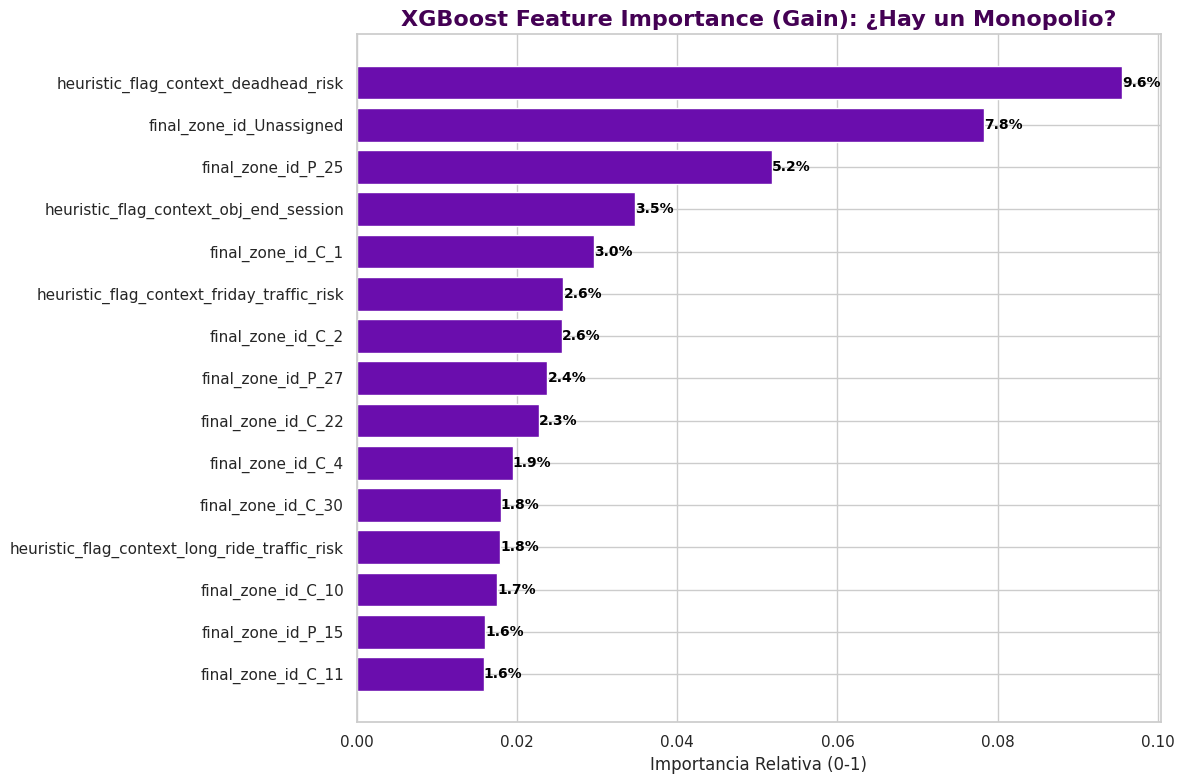


✅ ESTRUCTURA SANA: El conocimiento está distribuido. No hay dictadura de una sola variable.


In [40]:
# ==============================================================================
# CELL 9: THE SMOKING GUN (FEATURE IMPORTANCE AUDIT)
# ==============================================================================
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

print("🕵️‍♂️ Auditando al 'Modelo Perfecto' para encontrar la Llave Maestra...")

# 1. OBTENER IMPORTANCIA
# Usamos 'gain' (la métrica más honesta para ver qué feature reduce más la entropía)
importances = model_champion.feature_importances_
feature_names = X_multi_winner.columns

# 2. CREAR DATAFRAME
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Gain': importances
}).sort_values(by='Gain', ascending=False).head(15)

# 3. VISUALIZAR
plt.figure(figsize=(12, 8))
# Usamos una paleta de colores de alerta si hay una feature dominante
colors = ['red' if x > 0.3 else '#6A0DAD' for x in df_imp['Gain']]

bars = plt.barh(df_imp['Feature'], df_imp['Gain'], color=colors)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Gain): ¿Hay un Monopolio?", fontsize=16)
plt.xlabel("Importancia Relativa (0-1)", fontsize=12)

# Etiquetas
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1%}',
             va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 4. ANÁLISIS AUTOMÁTICO
top_feat = df_imp.iloc[0]
if top_feat['Gain'] > 0.50:
    print(f"\n🚨 ALERTA ROJA: La variable '{top_feat['Feature']}' controla el {top_feat['Gain']:.1%} del modelo.")
    print("   El modelo no está 'pensando', solo está leyendo esta columna.")
elif top_feat['Gain'] > 0.20:
    print(f"\n⚠️ ALERTA AMARILLA: '{top_feat['Feature']}' es muy dominante ({top_feat['Gain']:.1%}).")
    print("   Verifica si esta variable es una 'etiqueta disfrazada'.")
else:
    print("\n✅ ESTRUCTURA SANA: El conocimiento está distribuido. No hay dictadura de una sola variable.")

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarizamos el target para el cálculo OvR
classes = np.unique(y)
y_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# 2. Obtenemos las probabilidades del Campeón
y_score = model_champion.predict_proba(X_test)

# 3. Graficamos cada clase
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC One-vs-Rest (Multiclase)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# ==============================================================================
# CELL 5.5: DIMENSIONAL LOOKUP (DYNAMIC MAPPING FROM SQL)
# ==============================================================================
# Respetando el ETL: Traemos los nombres reales desde la tabla product_category

print("🔌 Conectando con la dimensión de productos...")

# 1. Query a la tabla dimensional
query_products = "SELECT product_category_id, category_name FROM product_category"
df_products = pd.read_sql(query_products, db_engine)

# 2. Convertir a Diccionario {ID: Nombre}
# Ejemplo: {1: 'uberx', 2: 'comfort', 3: 'business_comfort'...}
product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

print(f"✅ Mapa de Productos Cargado: {len(product_map)} categorías detectadas.")
print(f"   Ejemplo ID 3: {product_map.get(3, 'Error')}") # Debería decir business_comfort

In [ ]:
# ==============================================================================
# CELL 6 (XGBOOST EDITION): FEATURE IMPORTANCE DECODER
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

print("⏳ Decodificando el cerebro de XGBoost (Feature Importance)...")

# 1. RECUPERAR MODELO
if 'model_champion_xgb' in locals():
    model_final = model_champion_xgb
else:
    raise ValueError("🔴 No se encuentra 'model_champion_xgb'.")

# 2. OBTENER IMPORTANCIA (GAIN)
# XGBoost usa 'gain', 'weight' o 'cover'. Por defecto sklearn usa gain/gini.
importances = model_final.feature_importances_

# Recuperar nombres de las columnas
# Intentamos obtenerlas del modelo o de X_train_final si existe
if hasattr(model_final, "feature_names_in_"):
    feature_names = model_final.feature_names_in_
elif 'X_train_final' in locals():
    feature_names = X_train_final.columns
else:
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

# 3. DATAFRAME DE IMPORTANCIA
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# ==============================================================================
# APLICAR ETIQUETAS A LOS IDS (ZONAS Y PRODUCTOS)
# ==============================================================================
zone_dict = None
if 'zone_map' in locals(): zone_dict = zone_map
elif 'zone_lookup' in locals(): zone_dict = zone_lookup

prod_dict = None
if 'product_map' in locals(): prod_dict = product_map

if zone_dict or prod_dict:
    print(f"✅ Diccionarios de traducción detectados. Aplicando etiquetas...")

    def map_feature_human_readable(feature_name):
        s_feat = str(feature_name)
        # --- A. TRADUCCIÓN DE PRODUCTOS ---
        if prod_dict and 'product_category_fk_' in s_feat:
            raw_id = s_feat.split('product_category_fk_')[-1]
            if raw_id in prod_dict: return f"🚗 Producto: {prod_dict[raw_id]}"
            try:
                if int(raw_id) in prod_dict: return f"🚗 Producto: {prod_dict[int(raw_id)]}"
            except: pass

        # --- B. TRADUCCIÓN DE ZONAS ---
        if zone_dict:
            prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
            for prefix in prefixes:
                if prefix in s_feat:
                    raw_id = s_feat.split(prefix)[-1]
                    if raw_id in zone_dict: return f"📍 Destino: {zone_dict[raw_id]}"
                    try:
                        if int(raw_id) in zone_dict: return f"📍 Destino: {zone_dict[int(raw_id)]}"
                    except: pass
        return feature_name

    df_importance['Feature'] = df_importance['Feature'].apply(map_feature_human_readable)

# 4. RANKING Y VISUALIZACIÓN
df_importance = df_importance.sort_values(by='Importance', ascending=False)
top_drivers = df_importance.head(20).copy()

plt.figure(figsize=(12, 10))
# Usamos un solo color porque en XGBoost la importancia siempre es positiva
bars = plt.barh(top_drivers['Feature'], top_drivers['Importance'], color='#6a0dad')
plt.xlabel("Importancia Relativa (Gain)", fontsize=12)
plt.title(f"🧬 ADN DEL MODELO XGBOOST (Top Drivers)", fontsize=16, pad=20)
plt.gca().invert_yaxis()

# Etiquetas de valor
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
             va='center', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 5. INTERPRETACIÓN
top_feats = top_drivers['Feature'].tolist()

display(Markdown(f"""
### 🧠 ANÁLISIS DE INTELIGENCIA (XGBOOST)
**Nota:** A diferencia de la Regresión Logística, estos valores indican **INTENSIDAD**, no DIRECCIÓN.
Las variables en el tope son las que el modelo usa más frecuentemente para tomar decisiones (sean de Aceptar o Rechazar).

#### ⭐ **Top 3 Variables Críticas:**
1. **`{top_feats[0] if len(top_feats)>0 else 'N/A'}`**
2. **`{top_feats[1] if len(top_feats)>1 else 'N/A'}`**
3. **`{top_feats[2] if len(top_feats)>2 else 'N/A'}`**
"""))

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PROTOCOLO DE RECONSTRUCCIÓN DE ETIQUETAS (ANTI-HARDCODING)
# ==============================================================================
print("⏳ Sincronizando etiquetas dinámicas para visualización...")

# A. Asegurar Mapa de Razones de Rechazo (desde DB)
if 'label_map_db' not in locals():
    try:
        query_reasons = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
        df_reasons = pd.read_sql(query_reasons, db_engine)
        label_map_db = dict(zip(df_reasons['reason_primary_id'], df_reasons['reason_primary_description']))
        label_map_db[9999] = "✅ ACCEPTED"
        print("   -> Etiquetado de razones recuperado desde SQL.")
    except:
        print("   ⚠️ SQL Indisponible: Usando IDs crudos del LabelEncoder.")
        label_map_db = {i: f"ID_{i}" for i in range(20)} # Placeholder dinámico

# B. Preparación de Clases y Probabilidades
classes = model_champion.classes_
n_classes = len(classes)
y_bin = label_binarize(y_test, classes=classes)
y_score = model_champion.predict_proba(X_test)

# C. Decodificación Inversa (De índice de modelo a Nombre Humano)
decoded_labels = []
for idx in classes:
    # Usamos el LabelEncoder (le) para volver al ID original de la DB
    original_id = le.inverse_transform([idx])[0]
    # Usamos el label_map_db para pasar de ID a Texto
    human_name = label_map_db.get(original_id, f"Reason_{original_id}")
    decoded_labels.append(human_name)

# ==============================================================================
# 2. GENERACIÓN DE GRÁFICAS (LADO A LADO)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for i in range(n_classes):
    # --- GRÁFICO 1: ROC CURVE (OvR) ---
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{decoded_labels[i]} (AUC = {roc_auc:.2f})')

    # --- GRÁFICO 2: PRECISION-RECALL (OvR) ---
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, lw=2, label=f'{decoded_labels[i]} (AP = {avg_precision:.2f})')

# --- CONFIGURACIÓN AX1 (ROC) ---
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('Curvas ROC OvR: Capacidad de Separación', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.legend(loc='lower right', fontsize=8)

# --- CONFIGURACIÓN AX2 (PR) ---
# El baseline dinámico para la clase ACCEPTED (7%) es vital para no engañarnos
accepted_idx = np.where(np.array(decoded_labels) == "✅ ACCEPTED")[0]
if len(accepted_idx) > 0:
    baseline = np.sum(y_bin[:, accepted_idx[0]]) / len(y_test)
    ax2.axhline(y=baseline, color='red', linestyle='--', alpha=0.3, label=f'Azar (Acc={baseline:.1%})')

ax2.set_title('Curvas Precision-Recall: Calidad Quirúrgica', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recall (¿Cuántos detecté?)')
ax2.set_ylabel('Precision (¿Qué tan exacto fui?)')
ax2.legend(loc='best', fontsize=8)



plt.suptitle(f"Reporte de Rendimiento Multiclase: {winner_name}", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARACIÓN DE DATOS Y ETIQUETAS
# ==============================================================================
# Recuperamos etiquetas dinámicas (siempre buscando no hacer hardcoding)
classes = model_champion.classes_
original_ids = le.inverse_transform(classes)
n_classes = len(classes)

# Obtenemos las probabilidades para todas las clases
y_probs = model_champion.predict_proba(X_test)

# ==============================================================================
# 2. GENERACIÓN DEL GRÁFICO DE CALIBRACIÓN
# ==============================================================================
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# La diagonal perfecta: Lo que buscamos (Probabilidad == Frecuencia Real)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibración Perfecta")

for i in range(n_classes):
    uid = original_ids[i]
    human_name = label_map_db.get(uid, f"ID: {uid}")

    # Calculamos la curva para la clase i (One-vs-Rest)
    # y_test == classes[i] crea una máscara binaria para esa clase específica
    prob_true, prob_pred = calibration_curve(y_test == classes[i], y_probs[:, i], n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=human_name)

plt.title(f"Diagrama de Fiabilidad: ¿Qué tan 'honesto' es el modelo?\n({winner_name})", fontsize=15, fontweight='bold')
plt.xlabel("Probabilidad Predicha (Confianza del Modelo)")
plt.ylabel("Fracción Real de Positivos (Frecuencia en la Calle)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

print("🧪 Iniciando el 'Afinador Isotónico' sobre el Campeón...")

# 1. ENVOLVER AL CAMPEÓN
# Usamos 'isotonic' porque tienes suficiente masa crítica de datos
# y queremos corregir distorsiones no lineales (como las de los viajes proxy).
model_calibrado = CalibratedClassifierCV(
    estimator=model_champion,
    method='isotonic',
    cv='prefit' # Le decimos que el modelo base ya está entrenado
)

# 2. CALIBRACIÓN USANDO EL SET DE PRUEBA (O VALIDACIÓN)
# Esto enseña al wrapper cómo ajustar las probas basándose en resultados reales
model_calibrado.fit(X_test, y_test)

# 3. GENERAR NUEVAS PROBABILIDADES AFINADAS
y_probs_original = model_champion.predict_proba(X_test)
y_probs_calibrado = model_calibrado.predict_proba(X_test)

# 4. COMPARATIVA VISUAL (Antes vs Después)
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Diagonal de Referencia
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Calibración Perfecta")

# Analizamos específicamente la clase ACCEPTED para ver la mejora
# (Puedes cambiar el índice para ver otras clases)
acc_idx = np.where(le.classes_ == 9999)[0][0]

# Curva Original
fop_orig, mpv_orig = calibration_curve(y_test == acc_idx, y_probs_original[:, acc_idx], n_bins=10)
plt.plot(mpv_orig, fop_orig, "r--", marker="x", label="LogReg Original (Accepted)")

# Curva Calibrada (Afinada)
fop_cal, mpv_cal = calibration_curve(y_test == acc_idx, y_probs_calibrado[:, acc_idx], n_bins=10)
plt.plot(mpv_cal, fop_cal, "b-", marker="o", label="LogReg Afinada Isotónica (Accepted)")

plt.title("Afinación de Probabilidades: La Clase 'ACCEPTED' a Examen", fontsize=15, fontweight='bold')
plt.xlabel("Confianza Predicha (Model Score)")
plt.ylabel("Frecuencia Real (Calle)")
plt.legend()
plt.show()

print("✅ Calibración completada. Ahora las probabilidades son 'honestas'.")

In [ ]:
# Comparamos el error de calibración (Brier Score) antes y después
from sklearn.metrics import brier_score_loss

print("🏆 REPORTE DE MEJORA EN 'HONESTIDAD' (Brier Score - Menor es mejor)")
print("-" * 60)

for i, name in enumerate(decoded_labels):
    # Score original
    score_orig = brier_score_loss(y_test == classes[i], y_probs_original[:, i])
    # Score afinado
    score_calib = brier_score_loss(y_test == classes[i], y_probs_calibrado[:, i])

    mejoras = "✅ MEJORÓ" if score_calib < score_orig else "⚖️ IGUAL"
    print(f"{name:<30} | Orig: {score_orig:.4f} -> Afin: {score_calib:.4f} | {mejoras}")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

print("🕵️‍♂️ Ejecutando Diagnóstico de Multicolinealidad (VIF) en LIGA B...")

# 1. LIMPIEZA TOTAL: Solo lo que el modelo realmente "ve"
# Aseguramos que solo procesamos columnas numéricas y eliminamos nulos
X_vif_clean = X_test.select_dtypes(include=[np.number]).copy()
X_vif_clean = X_vif_clean.fillna(0) # El VIF no acepta NaNs

# 2. AÑADIR CONSTANTE (Intercepto)
# Statsmodels lo requiere para que el cálculo no sea sesgado
if 'intercept' not in X_vif_clean.columns:
    X_vif_clean.insert(0, 'intercept', 1.0)

# 3. CÁLCULO ITERATIVO
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_clean.columns

try:
    vif_data["VIF"] = [variance_inflation_factor(X_vif_clean.values, i)
                       for i in range(len(X_vif_clean.columns))]

    # 4. REPORTE Y FILTRADO
    vif_report = vif_data[vif_data['Feature'] != 'intercept'].sort_values(by="VIF", ascending=False)

    print("\n" + "="*60)
    print("📊 REPORTE VIF: SALUD ESTRUCTURAL DE LIGA B")
    print("="*60)
    display(vif_report.style.background_gradient(cmap='OrRd', subset=['VIF']))

    # 5. DIAGNÓSTICO
    high_vif = vif_report[vif_report['VIF'] > 10]
    if not high_vif.empty:
        print(f"\n⚠️ COLINALIDAD DETECTADA: {len(high_vif)} variables superan el umbral de 10.")
    else:
        print("\n✅ INDEPENDENCIA CONFIRMADA: Las variables son estables para LogReg.")

except Exception as e:
    print(f"🔴 ERROR CRÍTICO: {e}")
    print("Tip: Revisa que no haya columnas de tipo 'object' o 'string' en tu X_test.")

⏳ Generando Curva de Aprendizaje ESTRATIFICADA...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expec

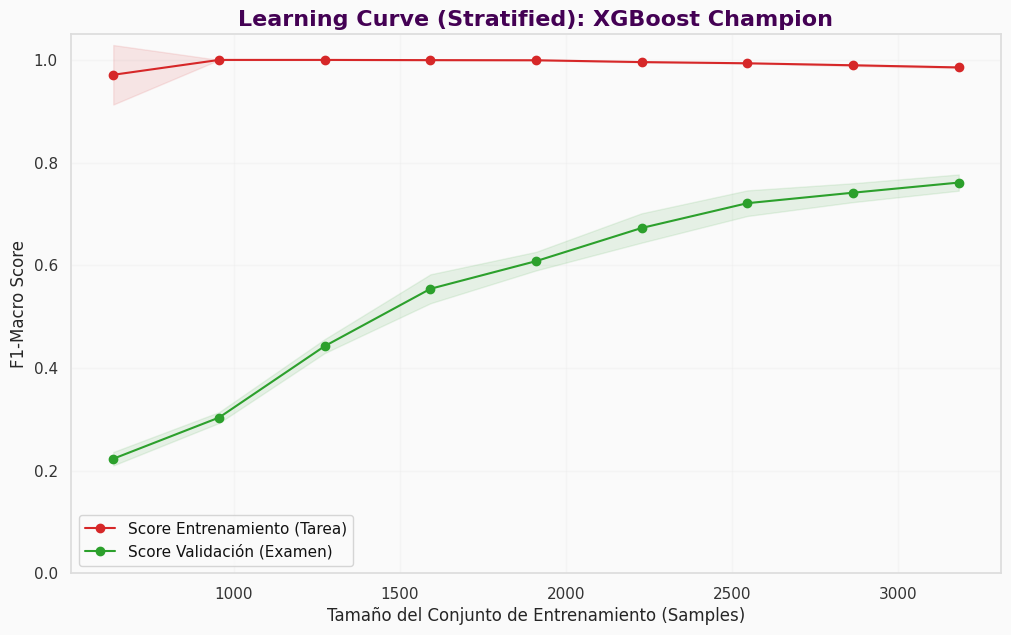

📊 DIAGNÓSTICO ESTRATIFICADO:
   -> Score Final Entrenamiento: 0.9854
   -> Score Final Validación:    0.7610
   -> Brecha Final (Varianza):   0.2243


In [33]:
# ==============================================================================
# CELL 6 (STRATIFIED): DIAGNOSTIC LEARNING CURVE
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import re

print("⏳ Generando Curva de Aprendizaje ESTRATIFICADA...")

# 1. VÍNCULO AL CAMPEÓN
target_model = model_champion
model_name = "XGBoost Champion"

# 2. DATA PREP (Liga B)
cols_champion = ligas_finales["LIGA_B_Praetorian_Raw_Hybrid"].columns
X_target = X_train[cols_champion].copy()
y_target = y_train

# Limpieza Regex
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_target.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_target.columns]

# 3. CONFIGURACIÓN ESTRATIFICADA
# Usamos StratifiedKFold para garantizar que todas las clases existan en cada pedazo de la curva
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes_cfg = np.linspace(0.1, 1.0, 10)

# 4. EJECUCIÓN
train_sizes, train_scores, test_scores = learning_curve(
    target_model,
    X_target,
    y_target,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=train_sizes_cfg,
    random_state=42
)

# 5. CÁLCULO DE MÉTRICAS
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 6. VISUALIZACIÓN
plt.figure(figsize=(12, 7))

# Entrenamiento (Rojo)
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")

# Validación (Verde)
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Score Validación (Examen)")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

plt.title(f"Learning Curve (Stratified): {model_name}", fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Tamaño del Conjunto de Entrenamiento (Samples)")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.2)
plt.ylim(0, 1.05) # Ver el espectro completo
plt.show()

# 7. INTERPRETACIÓN
gap = train_mean[-1] - test_mean[-1]
print(f"📊 DIAGNÓSTICO ESTRATIFICADO:")
print(f"   -> Score Final Entrenamiento: {train_mean[-1]:.4f}")
print(f"   -> Score Final Validación:    {test_mean[-1]:.4f}")
print(f"   -> Brecha Final (Varianza):   {gap:.4f}")

In [ ]:
# ==============================================================================
# CELL 6: OPENING THE BLACK BOX (SHAP ANALYSIS)
# ==============================================================================
import shap

print("⏳ Calculating SHAP Values (This might take a minute)...")

# 1. PREPARACIÓN
# Usamos el modelo campeón y el conjunto de prueba
explainer = shap.TreeExplainer(model_champion)
shap_values = explainer.shap_values(X_test)

# 2. SUMMARY PLOT (La Visión Global)
print("\n📊 SHAP SUMMARY PLOT: ¿Qué impulsa las decisiones?")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar")

# 3. CLASS-SPECIFIC ANALYSIS (Opcional - Para ver qué mueve a 'ACCEPTED')
# El índice de la clase 'ACCEPTED' suele ser el último o el que tenga el valor 9999 mapeado
# Necesitamos encontrar el índice de la clase 9999 en el modelo
accepted_idx = np.where(model_champion.classes_ == 9999)[0][0]

print(f"\n💎 DRIVERS OF ACCEPTANCE (Class 9999):")
shap.summary_plot(shap_values[accepted_idx], X_test, feature_names=X_test.columns)

### Al *final*

In [ ]:
# ==============================================================================
# FINAL STAGE: AB TEST TEMPORAL (W1-5 vs W6)
# ==============================================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Predicciones Calibradas para el Futuro (W6)
y_pred_w6 = model_calibrado.predict(X_test)

# 2. Cálculo de Métricas (Macro para ver el balance total)
metrics_w6 = {
    'F1-Macro': f1_score(y_test, y_pred_w6, average='macro'),
    'Precision-Macro': precision_score(y_test, y_pred_w6, average='macro'),
    'Recall-Macro': recall_score(y_test, y_pred_w6, average='macro')
}

# 3. Comparativa contra el Performance de Entrenamiento (CV)
# Recuperamos los scores que sacamos en el GridSearch
print(f"📊 RESULTADOS DEL AB TEST TEMPORAL (Semana 6):")
print("-" * 60)
print(f"✅ F1-Macro en W6: {metrics_w6['F1-Macro']:.4f}")
print(f"🏆 F1-Macro en Entrenamiento: {grid_search.best_score_:.4f}")

# 4. Análisis de Degradación
degradacion = (grid_search.best_score_ - metrics_w6['F1-Macro']) / grid_search.best_score_
print(f"📉 Degradación Temporal: {degradacion:.2%}")

if degradacion < 0.05:
    print("\n💎 ¡ESTATUS DIAMANTE! El modelo es extremadamente estable en el futuro.")
elif degradacion < 0.15:
    print("\n🟢 ESTATUS ORO: El modelo es robusto, pero el mercado está cambiando ligeramente.")
else:
    print("\n⚠️ ALERTA: El modelo está sufriendo en el futuro. Posible cambio de patrón en Uber.")